# Business Sales Performance Analytics

## Scope

- Clean and organize raw sales data (Excel or CSV format)

- Analyze:
  - Revenue trends over time
  - Top-selling products
  - High-value categories or regions

- Build a professional, client-ready dashboard or analysis report

- Write clear insights and recommendations as if advising a real business


### Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as ms

from statsmodels.tsa.seasonal import seasonal_decompose

import logging
import sweetviz as sw
import warnings # to ignoring warnings throughout project
warnings.filterwarnings("ignore")

C:\Users\KISHORE\anaconda3\envs\intern\Lib\site-packages\sweetviz\graph.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [2]:

sns.set_theme(
    style = "whitegrid",
    palette = "colorblind",
    context = "notebook"
)

plt.style.use("seaborn-v0_8") # this is useful for working with both seaborn and matplotlib togethore , and better visuval experiance

plt.rcParams.update({
    "axes.titlesize" : 12,
    "axes.labelsize" : 8,
    "axes.grid" : True,
    "font.size" : 4,
    "lines.linewidth" : 3
})

np.set_printoptions(precision = 4 , suppress = True)

pd.set_option("display.float_format" , "{:.4f}".format)

In [3]:
logging.basicConfig(
    filename = "logsfile.log",
    filemode = "w",
    level = logging.DEBUG,
    format = "%(asctime)s - %(levelname)s - %(message)s"
)

#### Dataset Description:
- With growing demands and cut-throat competitions in the market, a Superstore Giant is seeking your knowledge in understanding what works best for them. They would like to understand which products, regions, categories and customer segments they should target or avoid.

##### Features:

1. **Row ID**: Unique ID for each row.
2. **Order ID** : Unique Order ID for each Customer.
3. **Order Date** : Order Date of the product.
4. **Ship Date** : Shipping Date of the Product.
5. **Ship Mode**: Shipping Mode specified by the Customer.
6. **Customer ID** : Unique ID to identify each Customer.
7. **Customer Name** : Name of the Customer.
8. **Segment** : The segment where the Customer belongs.
9. **Country** : Country of residence of the Customer.
10. **City** : City of residence of of the Customer.
11. **State** : State of residence of the Customer.
12. **Postal Code** : Postal Code of every Customer.
13. **Region** : Region where the Customer belong.
14. **Product ID** : Unique ID of the Product.
15. **Category** : Category of the product ordered.
16. **Sub-Category** : Sub-Category of the product ordered.
17. **Product Name** : Name of the Product
18. **Sales** : Sales of the Product.
19. **Quantity** : Quantity of the Product.
20. **Discount** : Discount provided.
21. **Profit** : Profit/Loss incurred.

### Dataset Loading & Inspection

In [4]:
logging.info("csv file is reading...")
superstore_data = pd.read_csv("Sample Superstore.csv" , encoding = "latin1")
logging.info("csv file readed")

In [5]:
superstore_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.0000,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.0000,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.0000,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.4500,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.2000,2.5164


In [6]:
superstore_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

- superstore_data dataset have 9994 records and 21 columns with float , int , and object(string) data types.Total dataset size is 159904.
- Integer Data types of features are 'Postal Code', 'Quantity' , 'Row ID' , for float type 'Sales', 'Discount', 'Profit' features and object type features are 'Ship Mode', 'Segment', 'Country', 'City', 'State', 'Region','Category', 'Sub-Category', 'Product Name'.

In [7]:
list(superstore_data.columns)

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

### Data Cleaning

- Now , we need to cleane or prepare the dataset before do data analysis.

#### **Duplicate Records**

In [8]:
superstore_data[superstore_data.duplicated()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


- we can see there is **no any duplicate customer records** in superstore dataset.

#### **Handling Null Values**

In [9]:
superstore_data.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

- all columns in Superstore dataset **not have any null values**.
- there is no need to handle them.
- we can also see it as visuvaly.

<Axes: >

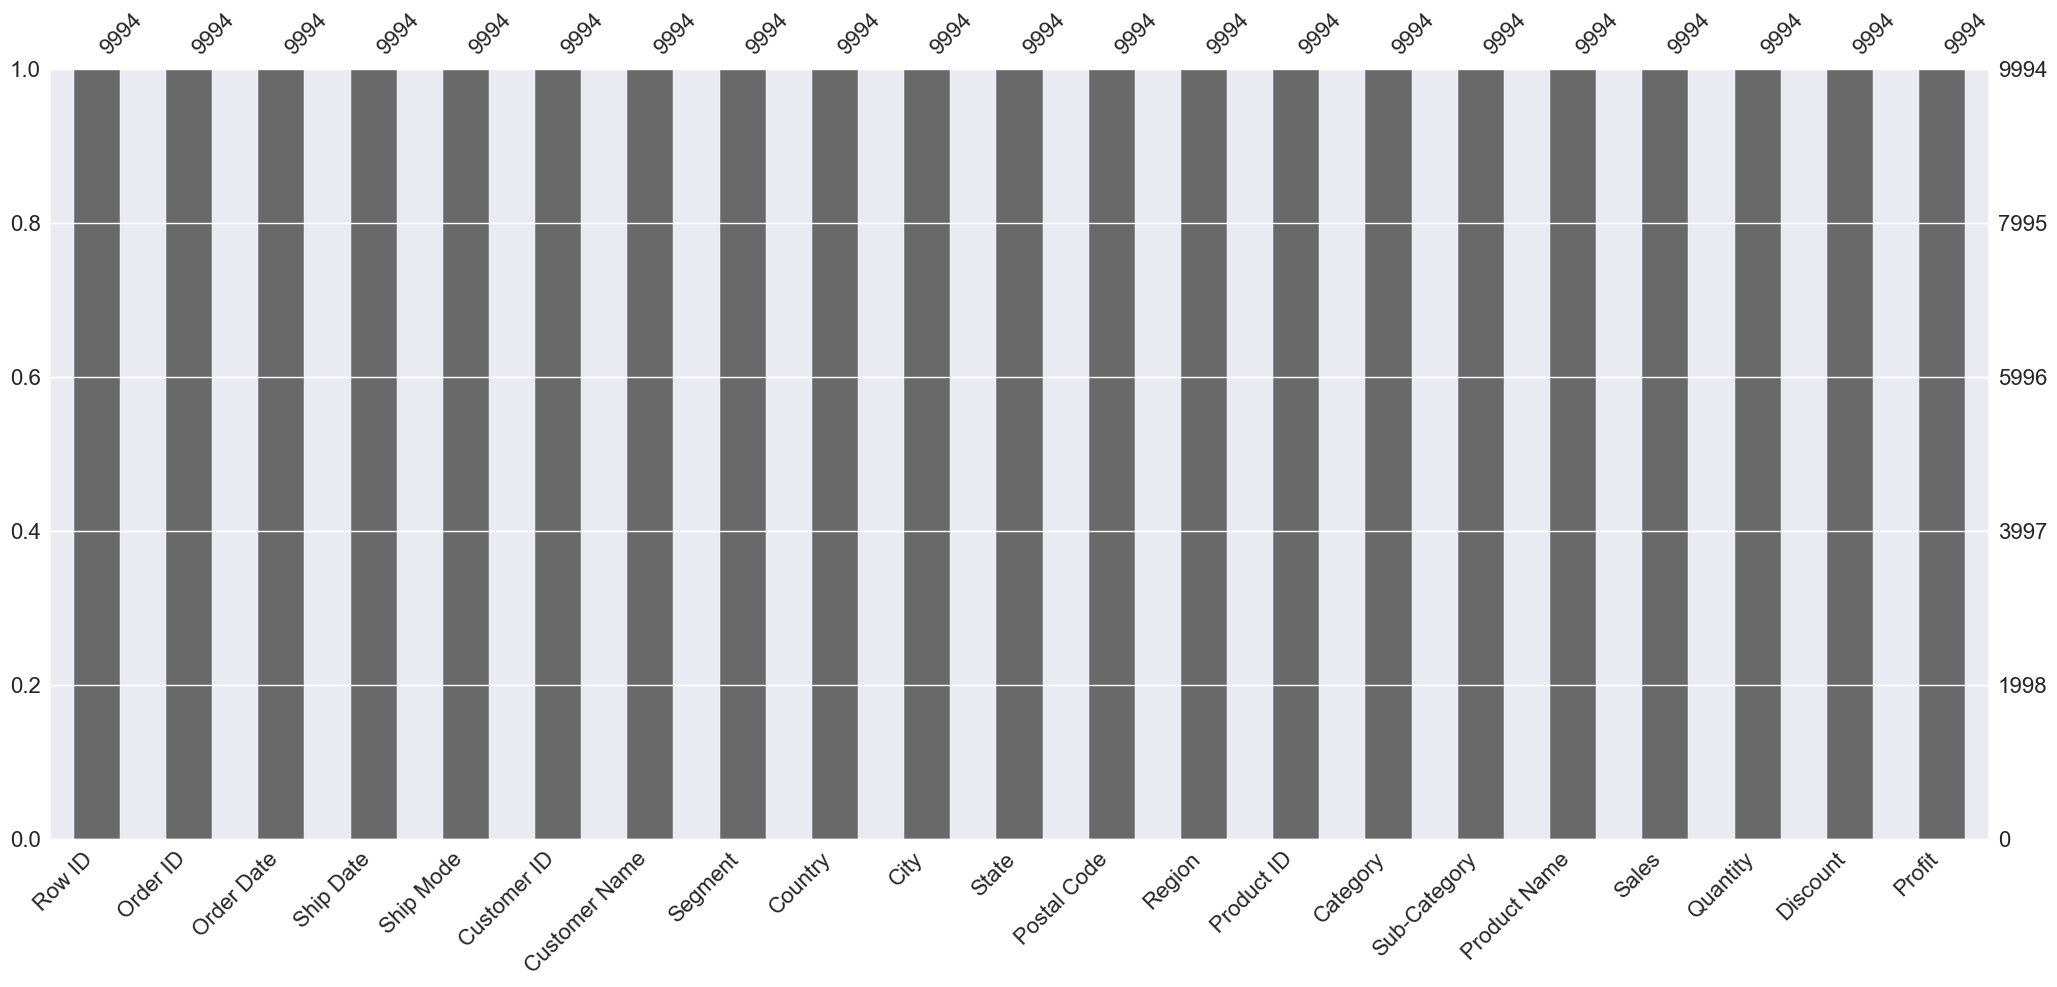

In [10]:
ms.bar(superstore_data)

#### **inconsistent Datatypes and Formating**

In [11]:
#in dataset Order Date column values are in 6/16/2016 it is not good for analysis , So this code format date as "/" to "-" 6-16-2016
superstore_data["Order Date"] = superstore_data["Order Date"].replace("/" , "-")
superstore_data["Ship Date"] = superstore_data["Ship Date"].replace("/" , "-")

#in dataset Order Date , Ship Date columns are has inconsistent datatypes , So convert to datetime format.
superstore_data["Ship Date"] = pd.to_datetime(superstore_data["Ship Date"])
superstore_data["Order Date"]= pd.to_datetime(superstore_data["Order Date"])

In [12]:
#removing features those are not importent for future analysis
superstore_data.drop(columns = ["Row ID" , "Customer ID" , "Customer Name" , "Product ID" , "Order ID"] , inplace = True)

In [13]:
superstore_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    9994 non-null   datetime64[ns]
 1   Ship Date     9994 non-null   datetime64[ns]
 2   Ship Mode     9994 non-null   object        
 3   Segment       9994 non-null   object        
 4   Country       9994 non-null   object        
 5   City          9994 non-null   object        
 6   State         9994 non-null   object        
 7   Postal Code   9994 non-null   int64         
 8   Region        9994 non-null   object        
 9   Category      9994 non-null   object        
 10  Sub-Category  9994 non-null   object        
 11  Product Name  9994 non-null   object        
 12  Sales         9994 non-null   float64       
 13  Quantity      9994 non-null   int64         
 14  Discount      9994 non-null   float64       
 15  Profit        9994 non-null   float64 

### Exploratory Data Analysis (EDA)

### Univariate Analysis

In [14]:
num_cols = superstore_data.select_dtypes(include = ["float64", "int64"]).columns
superstore_data[num_cols].drop(columns = "Postal Code").describe()

,Sales,Quantity,Discount,Profit
count,9994.0000,9994.0000,9994.0000,9994.0000
mean,229.8580,3.7896,0.1562,28.6569
std,623.2451,2.2251,0.2065,234.2601
min,0.4440,1.0000,0.0000,-6599.9780
25%,17.2800,2.0000,0.0000,1.7288
50%,54.4900,3.0000,0.2000,8.6665
75%,209.9400,5.0000,0.2000,29.3640
max,22638.4800,14.0000,0.8000,8399.9760


- above shows the basic statistical summary of numerical columns in superstore data.
- **Sales , Profit features are have high spread , and values are varing highly from central value.this suggest this two fatures are have outliers.**

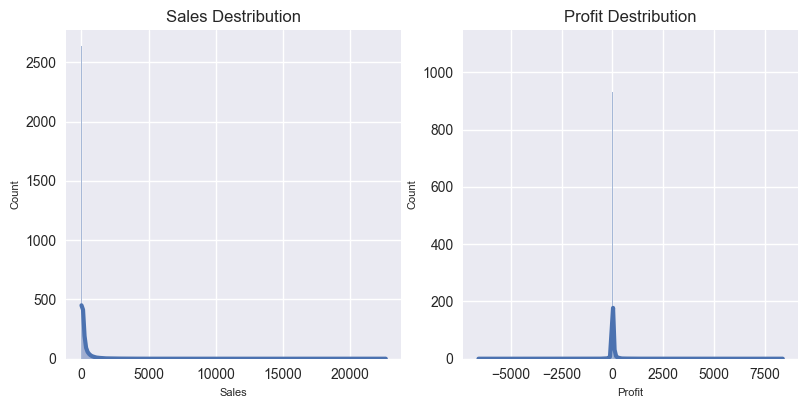

In [15]:
fig , axes = plt.subplots(1 , 2 , figsize = (8  , 4))
axes = axes.flatten()

for i , col in enumerate(["Sales" , "Profit"]):
    sns.histplot(x = superstore_data[col] ,  kde = True , ax = axes[i])
    axes[i].set_title(f"{col} Destribution")
plt.tight_layout()
plt.show()

#### **Outlier detection and Handling**

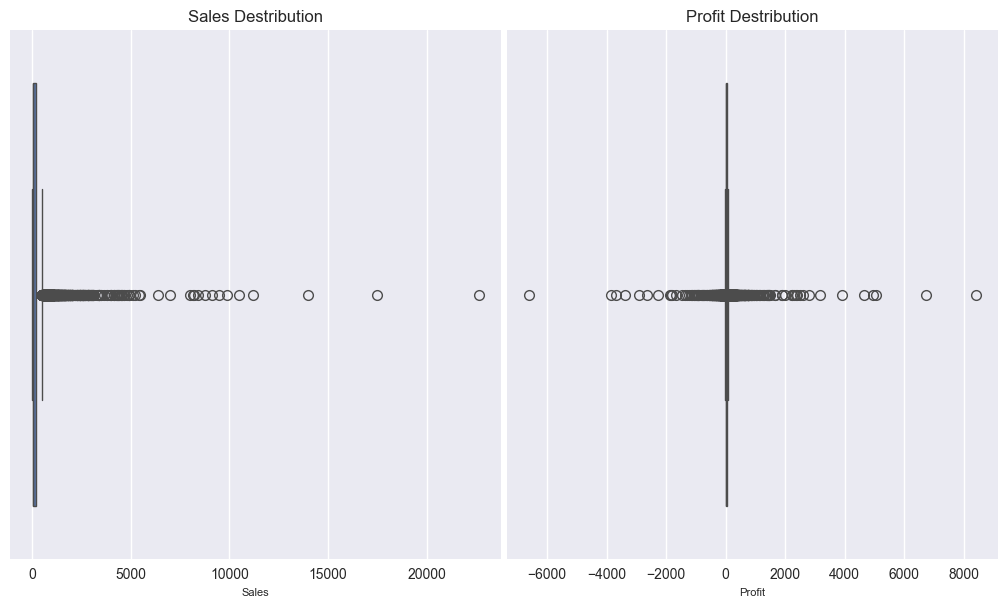

In [16]:
fig , axes = plt.subplots(1 , 2 , figsize = (10  , 6))
axes = axes.flatten()

for i , col in enumerate(["Sales" , "Profit"]):
    sns.boxplot(x = superstore_data[col], ax = axes[i])
    axes[i].set_title(f"{col} Destribution")
plt.tight_layout()
plt.show()

In [17]:
sales_median = superstore_data["Sales"].median()

Median_Absolute_Deviation = np.median(np.abs(superstore_data["Sales"] - sales_median))

modified_z_scores = 0.6745 * (superstore_data["Sales"] - sales_median) / Median_Absolute_Deviation

threshold = 0.7

outliers = superstore_data[np.abs(modified_z_scores) > threshold]

In [18]:
outliers.shape

(4667, 16)

In [19]:
clean_superstore_data = superstore_data[np.abs(modified_z_scores) <= threshold]

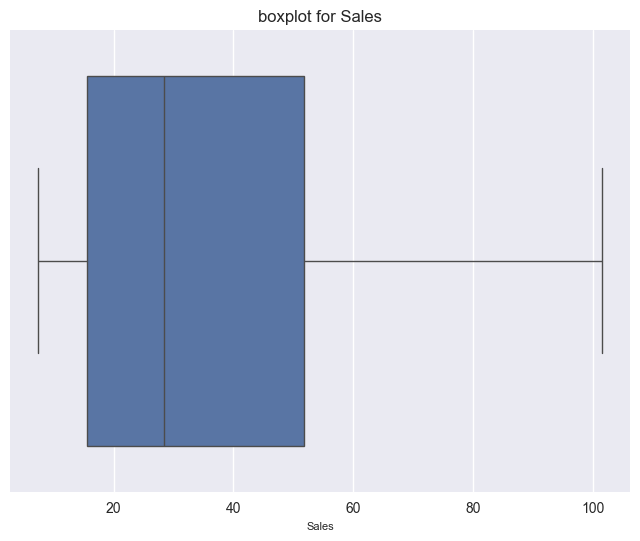

In [20]:
plt.figure(figsize = (8 , 6))

sns.boxplot( x = clean_superstore_data["Sales"])

plt.title("boxplot for Sales")
plt.show()

In [21]:
profit_median = clean_superstore_data["Profit"].median()

Median_Absolute_Deviation = np.median(np.abs(clean_superstore_data["Profit"] - profit_median))

modified_z_scores = 0.6745 * (clean_superstore_data["Profit"] - profit_median) / Median_Absolute_Deviation

threshold = 2.0

outliers = clean_superstore_data[np.abs(modified_z_scores) > threshold]
outliers.shape

(1197, 16)

In [22]:
cln_superstore_data = clean_superstore_data[np.abs(modified_z_scores) <= threshold]

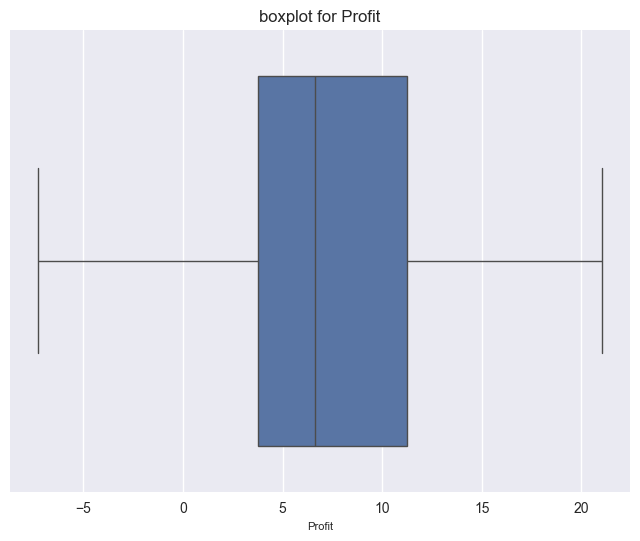

In [23]:
plt.figure(figsize = (8 , 6))

sns.boxplot( x = cln_superstore_data["Profit"])

plt.title("boxplot for Profit")
plt.show()

- After removing ouliears , the final cleaned dataset saved as cln_superstore_data.it is usefull for analysis.

In [24]:
cln_superstore_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4130 entries, 2 to 9992
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    4130 non-null   datetime64[ns]
 1   Ship Date     4130 non-null   datetime64[ns]
 2   Ship Mode     4130 non-null   object        
 3   Segment       4130 non-null   object        
 4   Country       4130 non-null   object        
 5   City          4130 non-null   object        
 6   State         4130 non-null   object        
 7   Postal Code   4130 non-null   int64         
 8   Region        4130 non-null   object        
 9   Category      4130 non-null   object        
 10  Sub-Category  4130 non-null   object        
 11  Product Name  4130 non-null   object        
 12  Sales         4130 non-null   float64       
 13  Quantity      4130 non-null   int64         
 14  Discount      4130 non-null   float64       
 15  Profit        4130 non-null   float64      

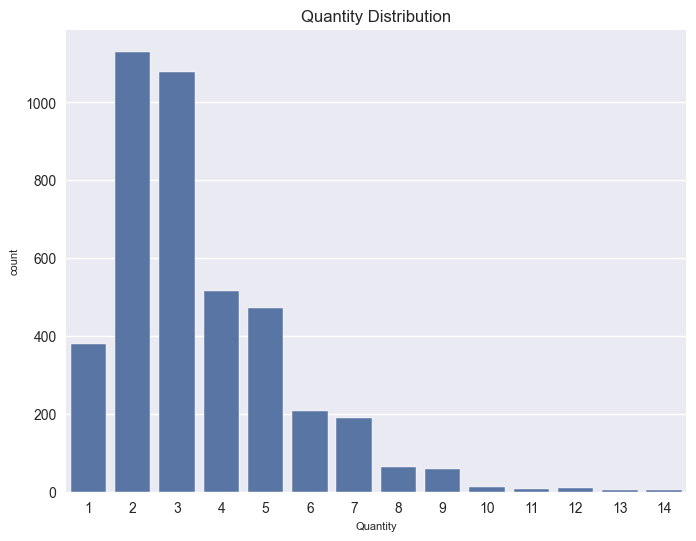

In [25]:
plt.figure(figsize = (8 , 6))

sns.countplot( x = cln_superstore_data["Quantity"])

plt.title("Quantity Distribution")
plt.show()

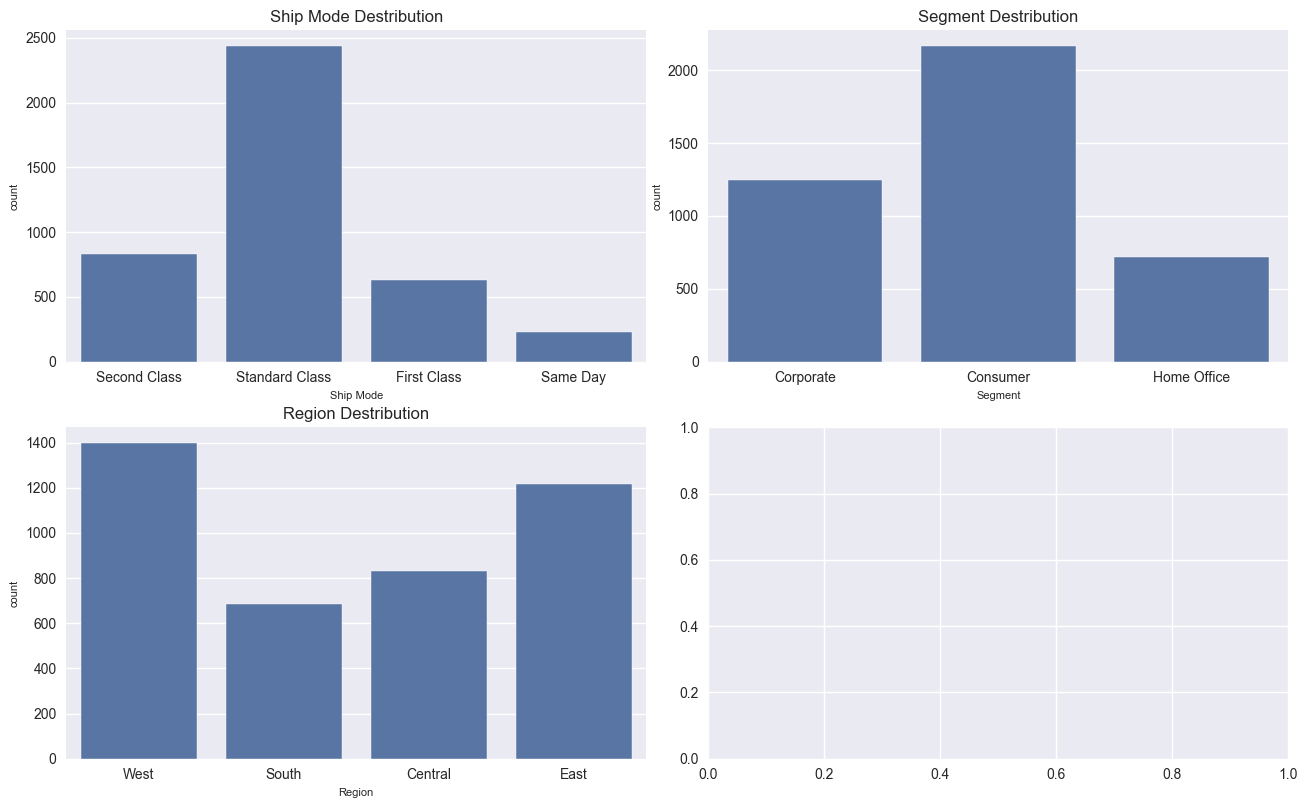

In [26]:
cat_cols = ["Ship Mode" , "Segment" , "Region"]

fig , axes = plt.subplots(2 , 2 , figsize = (13  , 8))
axes = axes.flatten()

for i , col in enumerate(cat_cols):
    sns.countplot(x = cln_superstore_data[col], ax = axes[i])
    axes[i].set_title(f"{col} Destribution")
plt.tight_layout()
plt.show()

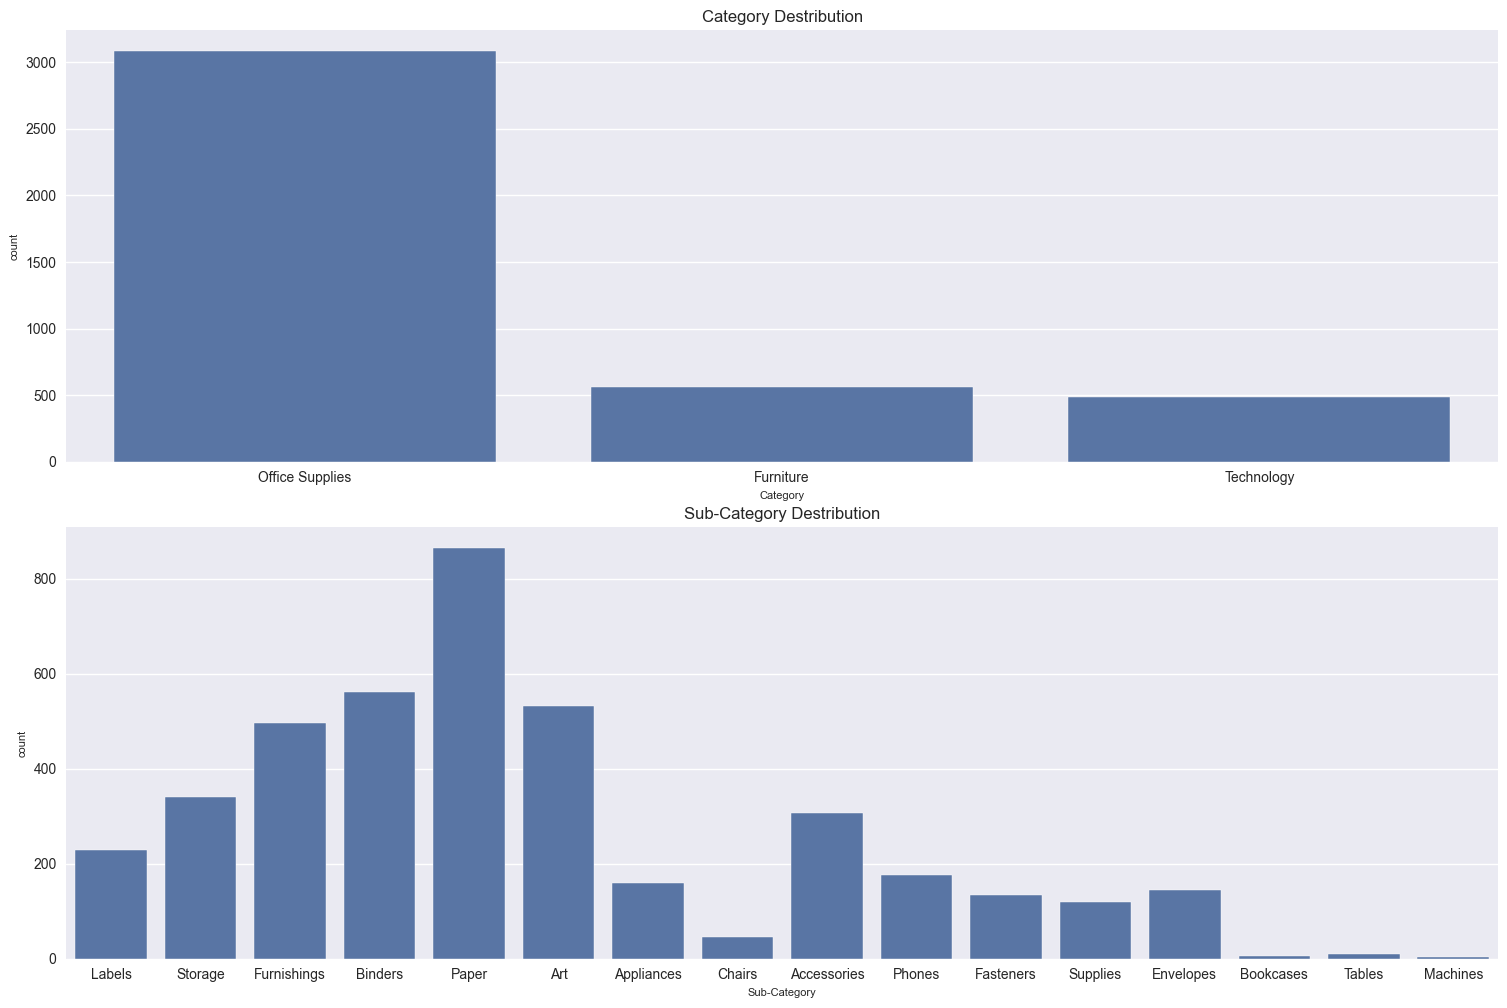

In [27]:
fig , axes = plt.subplots(2 , 1 , figsize = (15  , 10))
axes = axes.flatten()

for i , col in enumerate(["Category" , "Sub-Category"]):
    sns.countplot(x = cln_superstore_data[col], ax = axes[i])
    axes[i].set_title(f"{col} Destribution")
plt.tight_layout()
plt.show()

### Bivariate/Multivariate Analysis

**Business Question**: How do sales change over time?

In [28]:
cln_superstore_data_cp = cln_superstore_data.copy()

$$\text{Revenue} = (\text{Quantity} \times \text{Unit Price}) \times (1 - \text{Discount})$$

In [29]:
cln_superstore_data["Revenue"] = (cln_superstore_data["Quantity"] * cln_superstore_data["Sales"]) * (1 - cln_superstore_data["Discount"])

In [30]:
cln_superstore_data.to_excel("Superstore Sales Dataset.xlsx", index = False , sheet_name='Superstore Sales')

In [31]:
cln_superstore_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4130 entries, 2 to 9992
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    4130 non-null   datetime64[ns]
 1   Ship Date     4130 non-null   datetime64[ns]
 2   Ship Mode     4130 non-null   object        
 3   Segment       4130 non-null   object        
 4   Country       4130 non-null   object        
 5   City          4130 non-null   object        
 6   State         4130 non-null   object        
 7   Postal Code   4130 non-null   int64         
 8   Region        4130 non-null   object        
 9   Category      4130 non-null   object        
 10  Sub-Category  4130 non-null   object        
 11  Product Name  4130 non-null   object        
 12  Sales         4130 non-null   float64       
 13  Quantity      4130 non-null   int64         
 14  Discount      4130 non-null   float64       
 15  Profit        4130 non-null   float64      

**Business Question**: How do sales change over time?

<Axes: title={'center': 'Monthly Sales'}, xlabel='Order Date'>

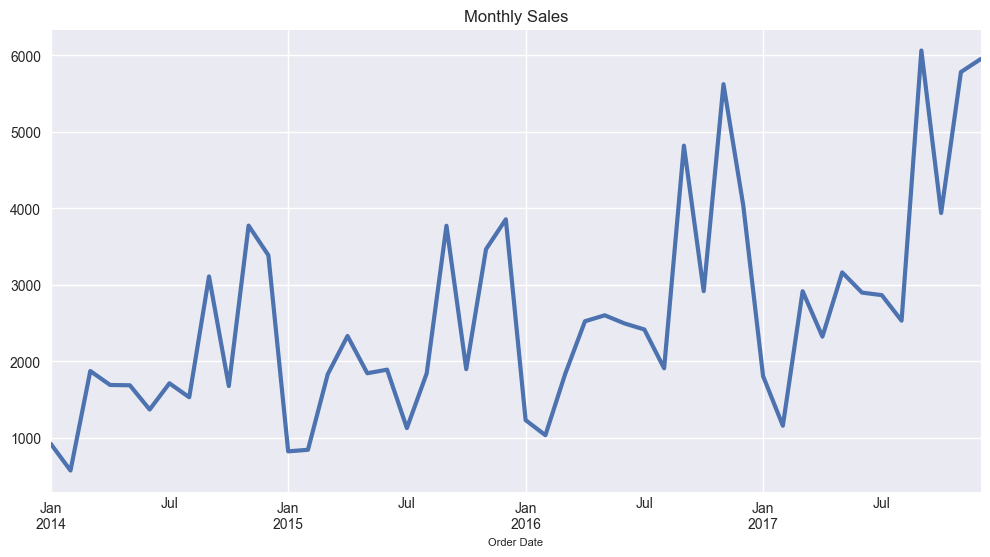

In [32]:
cln_superstore_data['Order Date'] = pd.to_datetime(cln_superstore_data['Order Date'])

cln_superstore_data.set_index('Order Date', inplace=True)

monthly_sales = cln_superstore_data['Sales'].resample('M').sum()

monthly_sales.plot(figsize=(12,6), title="Monthly Sales")

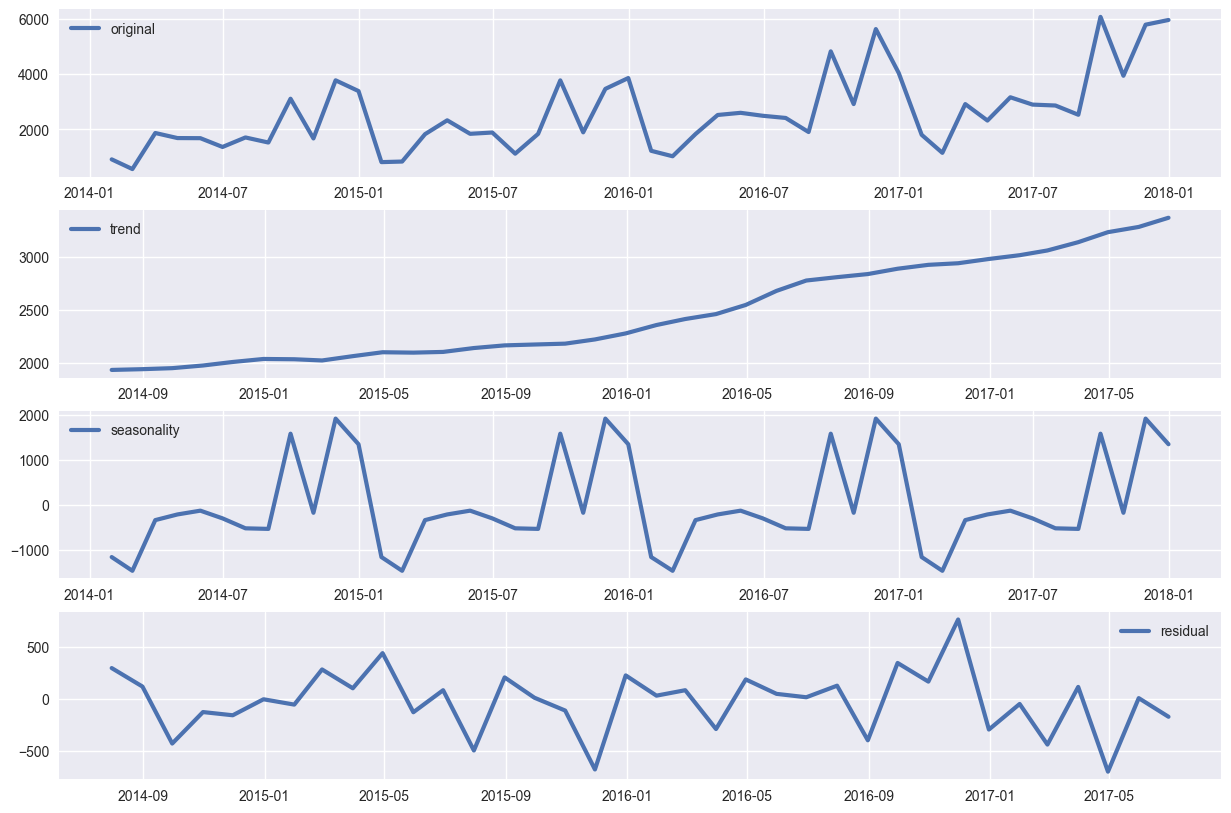

In [33]:
# applying additive seasonal decomposition on Sales

docompose_additive_model = seasonal_decompose(monthly_sales , model = "additive" , period = 12)

trend_additive = docompose_additive_model.trend
seasonality_additive = docompose_additive_model.seasonal
residual_additive = docompose_additive_model.resid

plt.figure(figsize = (15,10))
plt.subplot(411)
plt.plot(monthly_sales , label = "original")
plt.legend()
plt.subplot(412)
plt.plot(trend_additive , label = "trend")
plt.legend()
plt.subplot(413)
plt.plot(seasonality_additive , label = "seasonality")
plt.legend()
plt.subplot(414)
plt.plot(residual_additive , label = "residual")
plt.legend()
plt.show()

- Above visuvales clearly shows , there **increasing trend in mothly sales.**
- also, **Every 12 moths , mothly sales have seasonality means repeating  pattern , it is very use full for sales forcasting.**

**Business Question**: Which categories or regions are most profitable?

In [34]:
cln_superstore_data.groupby("Category")["Profit"].sum()

Category
Furniture          4189.6258
Office Supplies   24199.9962
Technology         3321.9102
Name: Profit, dtype: float64

In [35]:
cln_superstore_data.groupby("Region")["Profit"].sum()

Region
Central    5838.9343
East       9538.0533
South      5101.9402
West      11232.6044
Name: Profit, dtype: float64

In [36]:
cln_superstore_data.groupby(["Region" , "Category"])["Profit"].sum()

Region   Category       
Central  Furniture          232.3332
         Office Supplies   4868.0919
         Technology         738.5092
East     Furniture         1513.0181
         Office Supplies   7145.6874
         Technology         879.3478
South    Furniture          843.8486
         Office Supplies   3547.8714
         Technology         710.2202
West     Furniture         1600.4259
         Office Supplies   8638.3455
         Technology         993.8330
Name: Profit, dtype: float64

- **Office Supplies Category is high profitable** becouse total profit is upto 24199.9962 it is high among other categories such as Furniture 4189.6258, Technology 3321.9102.
- **East 9538.0533 regoin is high profitable** comparet to other regions.

**Business Question**: Which products generate the most revenue?

In [37]:
cln_superstore_data.groupby("Sub-Category")["Revenue"].sum()

Sub-Category
Accessories   40953.8692
Appliances    20965.9505
Art           52106.2040
Binders       45927.8683
Bookcases       500.8920
Chairs         4613.4210
Envelopes     10218.0132
Fasteners     13042.4396
Furnishings   49699.1440
Labels        18371.1492
Machines        104.4630
Paper         70503.4784
Phones        20295.0276
Storage       42993.5648
Supplies      14058.3168
Tables          747.8128
Name: Revenue, dtype: float64

In [38]:
cln_superstore_data.columns

Index(['Ship Date', 'Ship Mode', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit', 'Revenue'],
      dtype='object')

<Axes: title={'center': 'Monthly Revenue'}, xlabel='Order Date'>

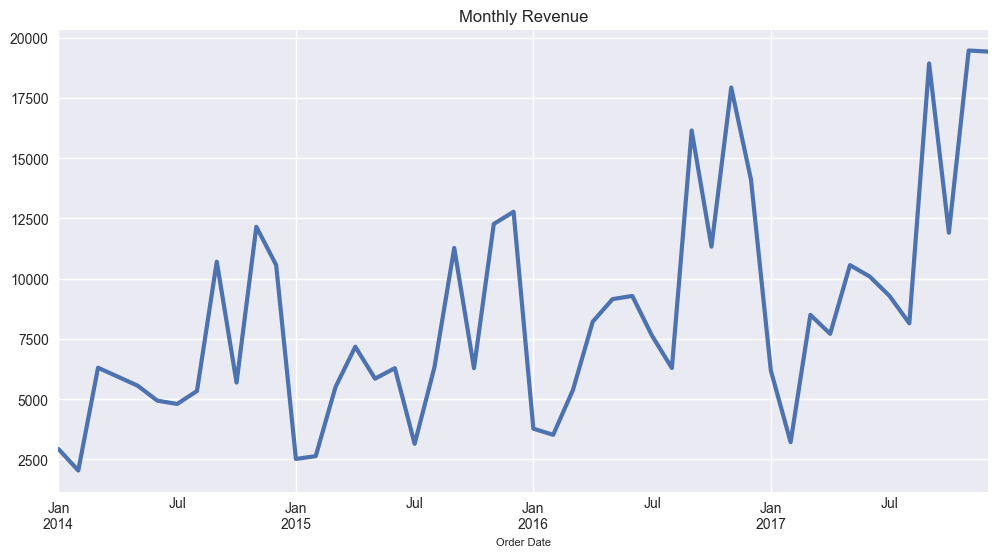

In [39]:
cln_superstore_data_cp["Revenue"] = cln_superstore_data["Revenue"] = (cln_superstore_data_cp["Quantity"] * cln_superstore_data_cp["Sales"]) * (1 - cln_superstore_data_cp["Discount"])

cln_superstore_data_cp.set_index('Order Date', inplace=True)

monthly_sales = cln_superstore_data_cp['Revenue'].resample('M').sum()

monthly_sales.plot(figsize=(12,6), title="Monthly Revenue")

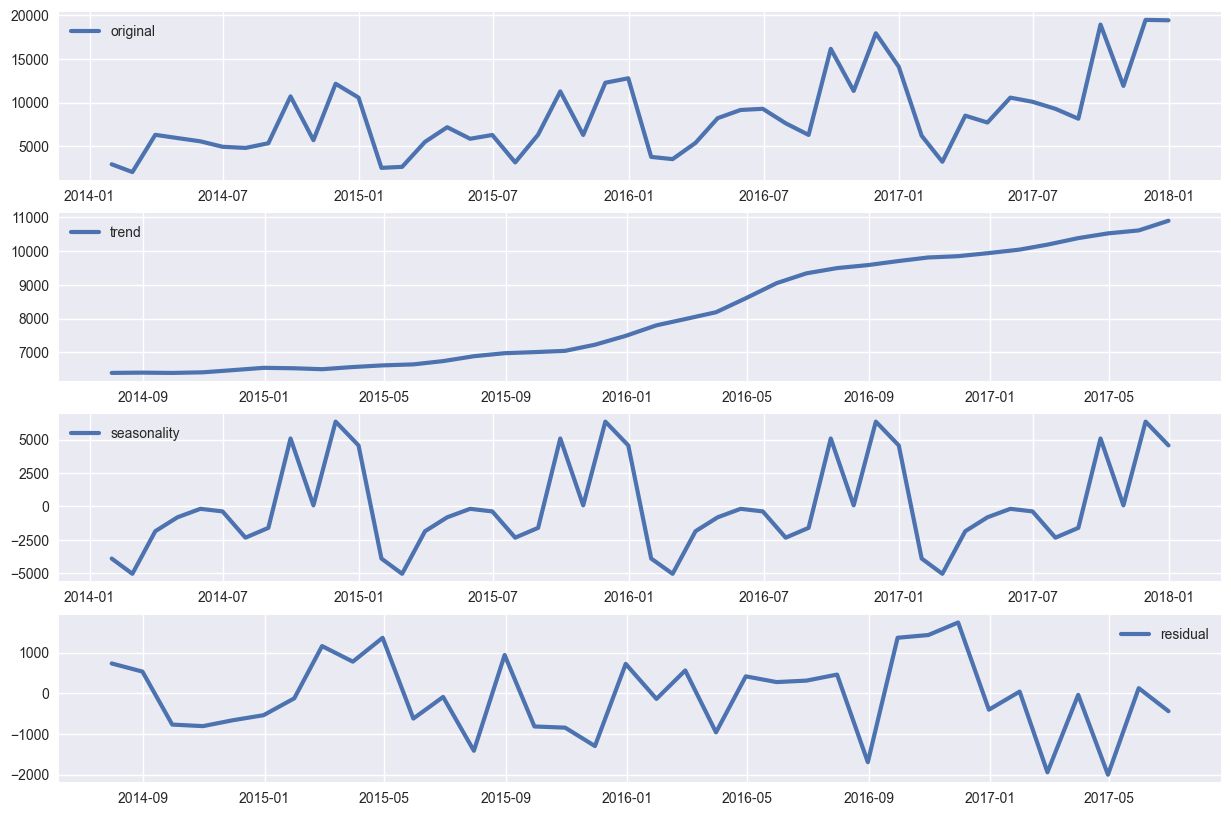

In [40]:
# applying additive seasonal decomposition on Revenue

docompose_additive_model = seasonal_decompose(monthly_sales , model = "additive" , period = 12)

trend_additive = docompose_additive_model.trend
seasonality_additive = docompose_additive_model.seasonal
residual_additive = docompose_additive_model.resid

plt.figure(figsize = (15,10))
plt.subplot(411)
plt.plot(monthly_sales , label = "original")
plt.legend()
plt.subplot(412)
plt.plot(trend_additive , label = "trend")
plt.legend()
plt.subplot(413)
plt.plot(seasonality_additive , label = "seasonality")
plt.legend()
plt.subplot(414)
plt.plot(residual_additive , label = "residual")
plt.legend()
plt.show()